array([[156, 157, 160, ..., 152, 152, 152],
       [156, 157, 159, ..., 152, 152, 152],
       [158, 157, 156, ..., 152, 152, 152],
       ...,
       [121, 123, 126, ..., 121, 113, 111],
       [121, 123, 126, ..., 121, 113, 111],
       [121, 123, 126, ..., 121, 113, 111]], dtype=uint8)
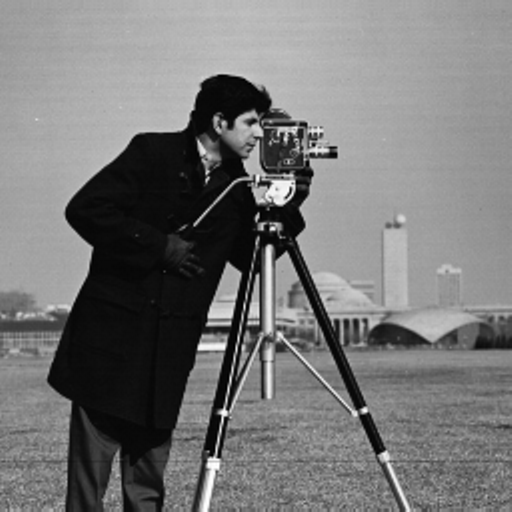

In [109]:
import cv2
import requests
import numpy as np
import matplotlib.pyplot as plt
def get_img(url):
    resp = requests.get(url)
    return cv2.imdecode(np.frombuffer(resp.content, np.uint8), cv2.IMREAD_GRAYSCALE)

img = get_img("https://raw.githubusercontent.com/ashish-kmr/BTP_inpaint/master/cameraman.tif")

img

In [110]:
cv2.imwrite('/content/output.jpg', img)

True

# Tasks

1.	Increase the size of the image.
2.	Rotate the image by 120 degrees.
3.	Perform Sheer operations over the image.

1.	Create a Negative Image
2.	Log with (choose an appropriate constant for your image)
3.	Power law (choose a value for gamma that increases the contrast)


array([[156, 156, 157, ..., 152, 152, 152],
       [156, 156, 157, ..., 152, 152, 152],
       [156, 156, 157, ..., 152, 152, 152],
       ...,
       [121, 122, 123, ..., 114, 112, 111],
       [121, 122, 123, ..., 114, 112, 111],
       [121, 122, 123, ..., 114, 112, 111]], dtype=uint8)
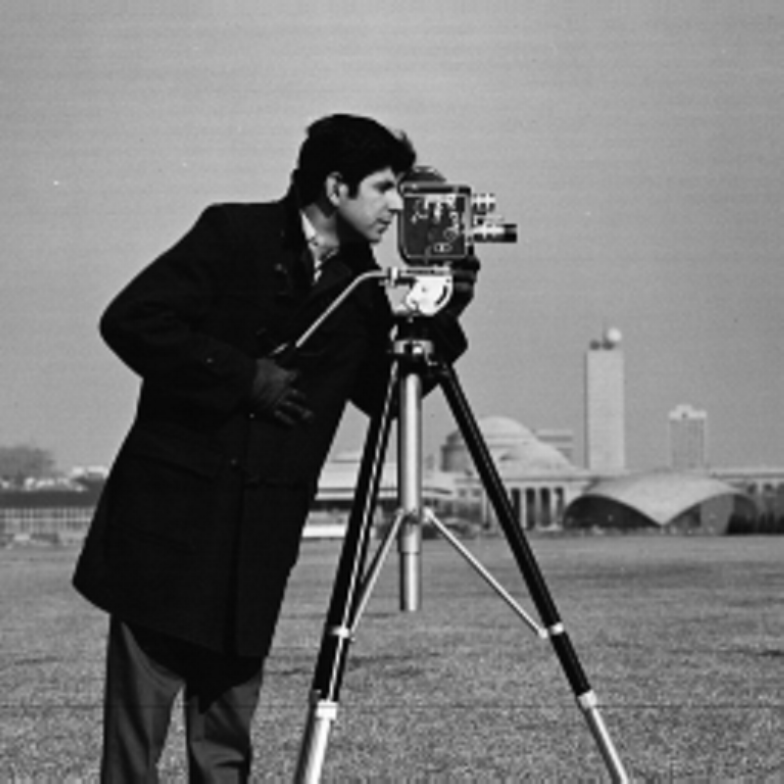

In [111]:
# 1.	Increase the size of the image.
cv2.resize(img, (784, 784))

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
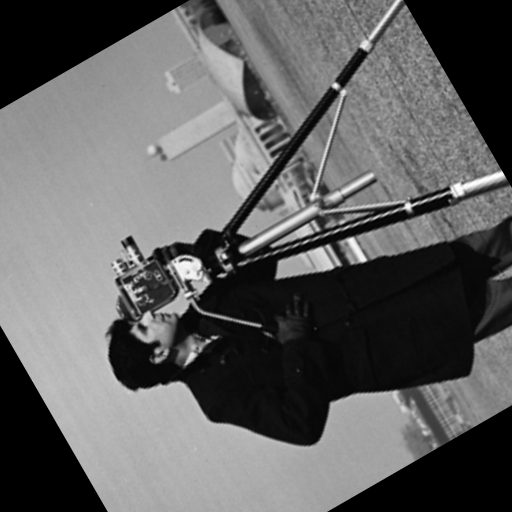

In [112]:
# 2.	Rotate the image by 120 degrees.
h, w = img.shape[:2]
M = cv2.getRotationMatrix2D((w / 2, h / 2), 120, 1)
rotated = cv2.warpAffine(img, M, (w, h))
rotated

array([[156, 157, 160, ..., 152, 152, 152],
       [ 78, 156, 158, ..., 152, 152, 152],
       [  0, 158, 157, ..., 153, 152, 152],
       ...,
       [  0,   0,   0, ..., 110, 124, 123],
       [  0,   0,   0, ..., 101, 117, 130],
       [  0,   0,   0, ..., 100, 110, 124]], dtype=uint8)
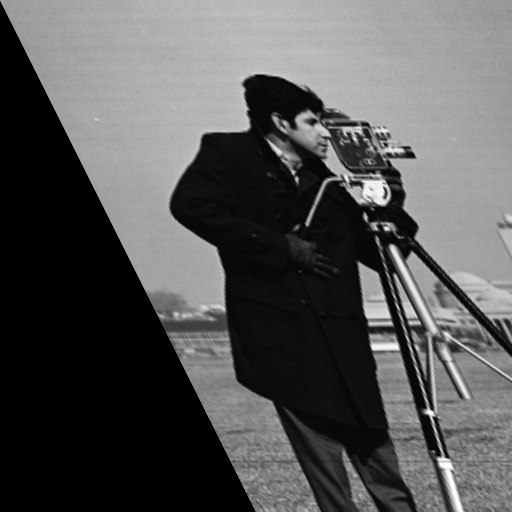

In [113]:
# 3.	Perform Sheer operations over the image.
h, w = img.shape[:2]
M = np.float32([[1, 0.5, 0], [0, 1, 0]])
sheared = cv2.warpAffine(img, M, (w, h))
sheared

array([[ 99,  98,  95, ..., 103, 103, 103],
       [ 99,  98,  96, ..., 103, 103, 103],
       [ 97,  98,  99, ..., 103, 103, 103],
       ...,
       [134, 132, 129, ..., 134, 142, 144],
       [134, 132, 129, ..., 134, 142, 144],
       [134, 132, 129, ..., 134, 142, 144]], dtype=uint8)
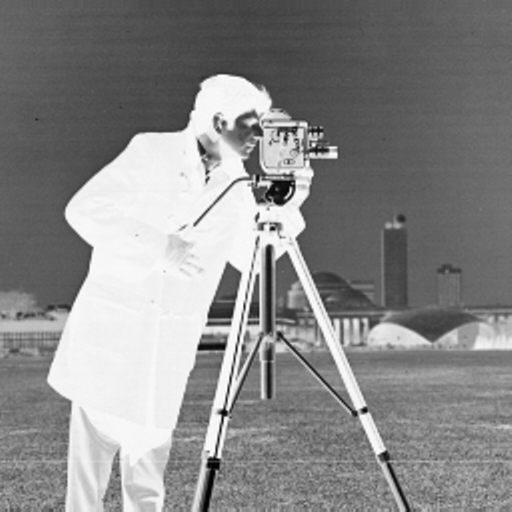

In [114]:
# 1.	Create a Negative Image
negative = cv2.bitwise_not(img)
negative

array([[151, 151, 152, ..., 150, 150, 150],
       [151, 151, 152, ..., 150, 150, 150],
       [152, 151, 151, ..., 150, 150, 150],
       ...,
       [144, 144, 145, ..., 144, 142, 141],
       [144, 144, 145, ..., 144, 142, 141],
       [144, 144, 145, ..., 144, 142, 141]], dtype=uint8)
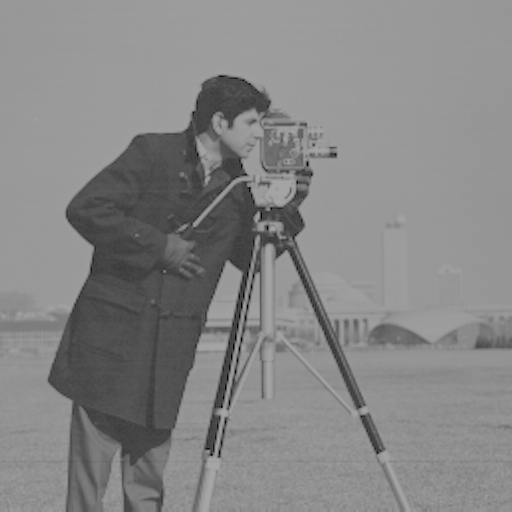

In [121]:
img_float = img.astype(np.float32)

c = 30
log_img = c * np.log(1 + img_float)

log_img = log_img.astype(np.uint8)
log_img

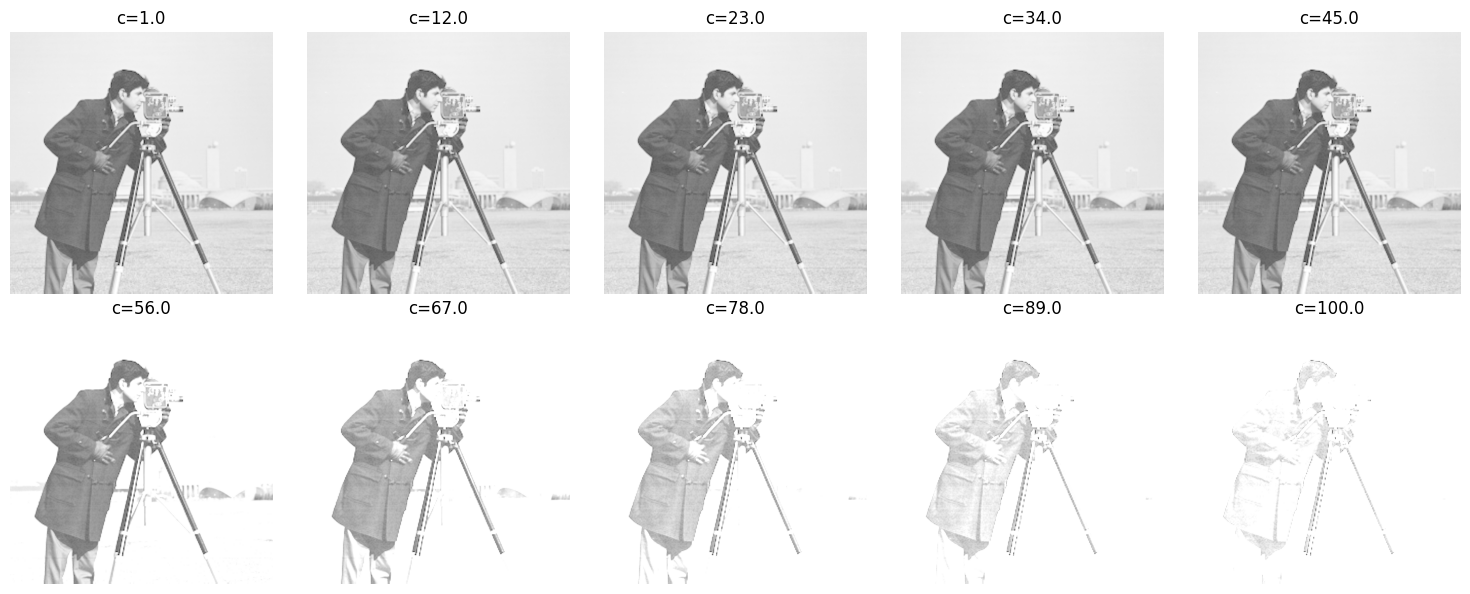

In [116]:
fig, axs = plt.subplots(2,5,figsize=(15,6)); [((axs.flat[i].imshow(np.clip(c*np.log1p(img.astype(float)),0,255),cmap='gray')), axs.flat[i].set_title(f'c={c:.1f}'), axs.flat[i].axis('off')) for i,c in enumerate(np.linspace(1,100,10))]; plt.tight_layout(); plt.show()

array([[199, 200, 201, ..., 196, 196, 196],
       [199, 200, 201, ..., 196, 196, 196],
       [200, 200, 199, ..., 196, 196, 196],
       ...,
       [175, 177, 179, ..., 175, 169, 168],
       [175, 177, 179, ..., 175, 169, 168],
       [175, 177, 179, ..., 175, 169, 168]], dtype=uint8)
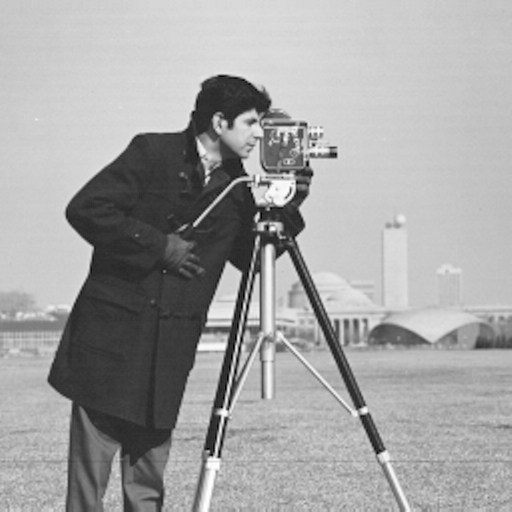

In [122]:
gamma = 0.5
power_img = np.uint8(255 * (img / 255.0) ** gamma)
power_img

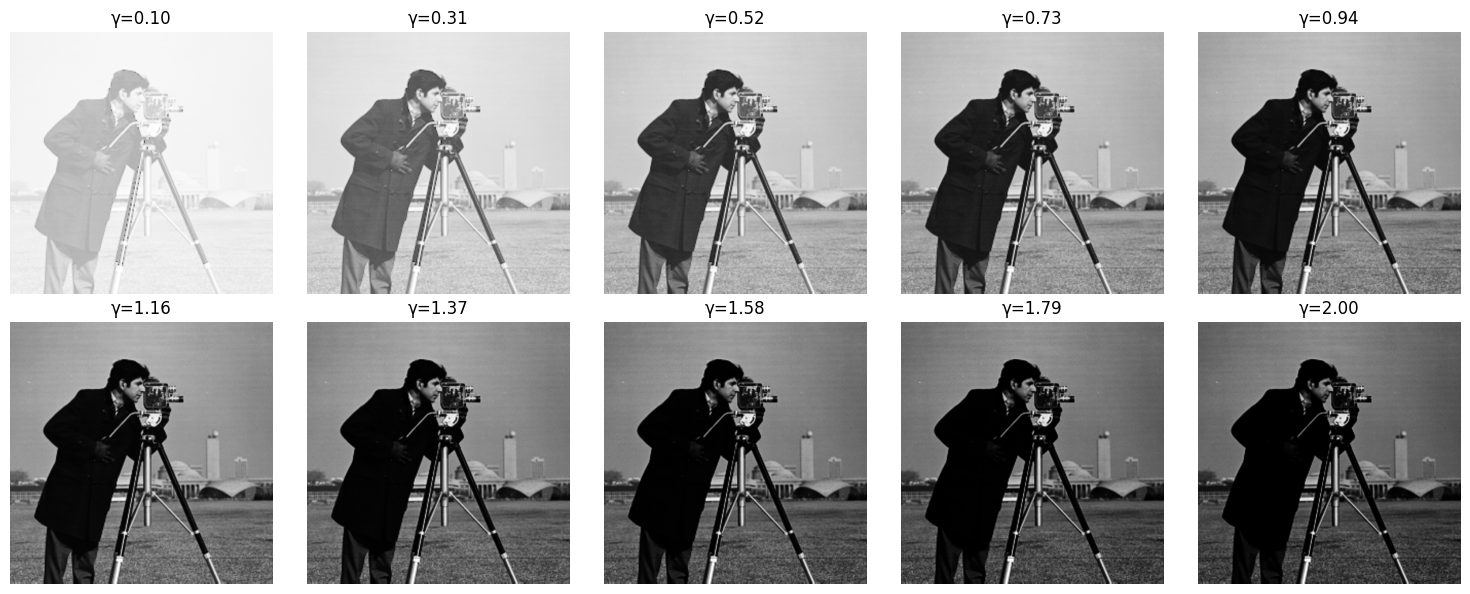

In [118]:
fig, axs = plt.subplots(2,5,figsize=(15,6)); [((axs.flat[i].imshow(255*(img/255.0)**g,cmap='gray')), axs.flat[i].set_title(f'γ={g:.2f}'), axs.flat[i].axis('off')) for i,g in enumerate(np.linspace(0.1,2,10))]; plt.tight_layout(); plt.show()